In [5]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = False # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(conversational_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: False, Database: mondial


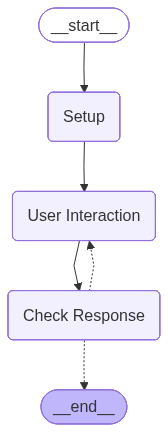

In [7]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [8]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]
    try: 
        # Se o experimento já foi avaliado, pula para o próximo
    
        if exp_id in processed_ids:
            print(f"Pulando experimento {exp_id} já processado.")
            continue

        print(f"Processando experimento {exp_id}...")

        config =  {"recursion_limit": 50}
        # Invoca a avaliação com as configurações estendidas
        eval_result = eval_graph.invoke({
            "experiment": experiment,
            "max_retries": 2,
            "debug_mode": True,
            "model_version": model_version,
            "experiment_type": experiment_type,
           
        }, config=config)

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get("experiment_config", {
                "max_retries": 2,
                "model_version": model_version,
                "timestamp": datetime.now().isoformat(),
                "experiment_type": experiment_type
            }),
            "experiment_eval": eval_result["experiment_eval"]
        })

        # Atualiza o arquivo salvando o resultado atual
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)
    except Exception as e:
        print(f"Erro ao processar experimento {exp_id}: {e}")


Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Can you list the airports along with their cities and countries?


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "List all airports along with their cities and countries.",
    "schema_linking": ["airport"],
    "answer": "Here are some airports along with their cities and countries: Tancredo Neves Intl in Belo Horizonte, Brazil; Marechal Cunha Machado Intl in São Luís, Brazil; Amarais Airport in Campinas, Brazil; Viracopos in Campinas, Brazil; Santa Maria in Aracaju, Brazil. There are a total of 1318 entries available.",
    "sql": "SELECT a.name AS airport_name, a.city AS city_name, a.country AS country_code FROM mondial_gpt.airport a"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "List all airports along with their cities and countries.",
    "schema_linking": ["airport"],
    "answer": "Here are some airports along with their cities and countries: Tancredo Neves Intl in Belo Horizonte, Brazil; Marechal Cunha Machado Intl in São Luís, Brazil; Amarais Airport 

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['NAME', 'CITY', 'COUNTRY'], dtype='object')
Adj. True cols: Index(['NAME', 'CITY', 'COUNTRY'], dtype='object')
Predicted cols: Index(['AIRPORT_NAME', 'CITY_NAME', 'COUNTRY_CODE'], dtype='object')
Adj. Predicted cols: Index(['AIRPORT_NAME', 'CITY_NAME', 'COUNTRY_CODE'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'List the airports along with their cities and countries.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Can you list the airports along with their cities and countries?', 'agent_reply': 'Here are some airports along with their cities and countries: Tancredo Neves Intl in Belo Horizonte, Brazil; Marechal Cunha Machado Intl in São Luís, Brazil; Amarais Airport in Campinas, Brazil; Viracopos in Campinas, Brazil; Santa Maria in Aracaju, Brazil. There are a total of 1318 entries available.', 'evaluation': {'text_to_sql_input': 'List all airports along with their cities and

KeyboardInterrupt: 